# Data visualization

Load smiles data:

In [47]:
import pandas as pd

df = pd.read_csv("../my_data/structures_smiles.csv")
df.head()

,Canonical_SMILES,drugbank_id,ChEMBL ID,zincid
0,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,1.0,NaN,NaN
1,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,2.0,NaN,NaN
2,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...,3.0,NaN,NaN
3,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,4.0,NaN,NaN
4,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,5.0,NaN,NaN


Let's calculate descriptors:

In [48]:
from rdkit import Chem
from rdkit.Chem import Descriptors

# some drug relevant descriptors
def get_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return {
            'MW': Descriptors.MolWt(mol),
            'LogP': Descriptors.MolLogP(mol),
            'HBD': Descriptors.NumHDonors(mol),     # H donors
            'HBA': Descriptors.NumHAcceptors(mol),  # H acceptors
            'TPSA': Descriptors.TPSA(mol)           # cell permeability
        }
    return None

In [49]:
desc_df = df['Canonical_SMILES'].apply(get_descriptors).apply(pd.Series)
df = pd.concat([df, desc_df], axis=1)
df.head()

,Canonical_SMILES,drugbank_id,ChEMBL ID,zincid,MW,LogP,HBD,HBA,TPSA
0,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,1.0,NaN,NaN,2180.317,-8.11643,28.0,29.0,901.57
1,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,2.0,NaN,NaN,1269.433,-3.10570,17.0,16.0,495.89
2,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...,3.0,NaN,NaN,1069.238,-4.13203,14.0,15.0,435.41
3,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,4.0,NaN,NaN,1431.064,-0.50613,17.0,16.0,495.67
4,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,5.0,NaN,NaN,1202.635,3.26900,5.0,12.0,278.80


And now...a little bit of graphic:

C:\Users\souku\AppData\Local\Temp\ipykernel_14780\668017228.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Database', y='TPSA', palette='Set2', log_scale=True)


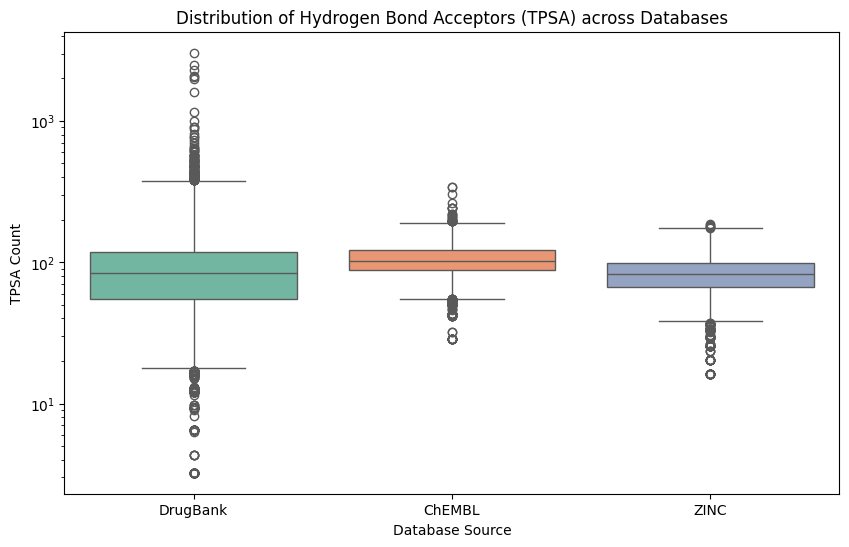

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

def show_boxplot_TPSA(df):
    db_map = {'drugbank_id': 'DrugBank', 'ChEMBL ID': 'ChEMBL', 'zincid': 'ZINC'}
    plot_data = pd.concat([
        df[df[col].notna()].assign(Database=name)[['Database', 'TPSA']]
        for col, name in db_map.items()
    ])

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=plot_data, x='Database', y='TPSA', palette='Set2', log_scale=True)

    plt.title('Distribution of Hydrogen Bond Acceptors (TPSA) across Databases')
    plt.xlabel('Database Source')
    plt.ylabel('TPSA Count')
    plt.show()

show_boxplot_TPSA(df)

So argument log_scale makes that we can see it better.
What if we delete outliers? :D

In [51]:
Q1 = df['TPSA'].quantile(0.25)
Q3 = df['TPSA'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Filter the DataFrame
df_clean = df[(df['TPSA'] >= lower_bound) & (df['TPSA'] <= upper_bound)]

print(f"Removed {len(df) - len(df_clean)} outliers.")

Removed 921 outliers.


C:\Users\souku\AppData\Local\Temp\ipykernel_14780\668017228.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Database', y='TPSA', palette='Set2', log_scale=True)


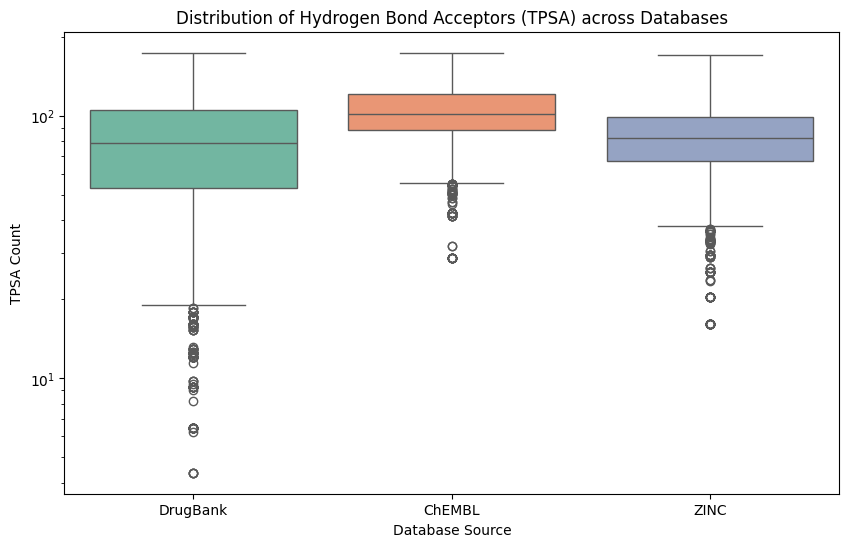

In [52]:
show_boxplot_TPSA(df_clean)

Now it is clearer.

What can we do now?
If we have HBA, does it means that it is more soluble? Let's see the scatter plot.
LogP show us how much the molecule is hydrophobic or hydrophilic.

We can see on the scatter plot if LogP is correlated with HBA:

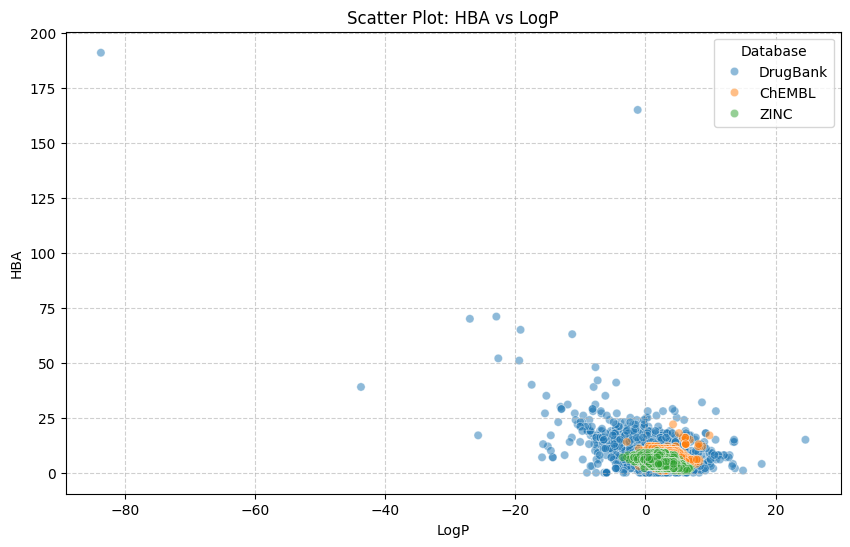

In [53]:
def show_scatterplot_HBA_LogP(df):
    db_map = {'drugbank_id': 'DrugBank', 'ChEMBL ID': 'ChEMBL', 'zincid': 'ZINC'}
    plot_data = pd.concat([
        df[df[col].notna()].assign(Database=name)
        for col, name in db_map.items()
    ])

    # 3. Create Scatter Plot (HBA vs Molecular Weight)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=plot_data, x='LogP', y='HBA', hue='Database', alpha=0.5)
    plt.title('Scatter Plot: HBA vs LogP')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
show_scatterplot_HBA_LogP(df)

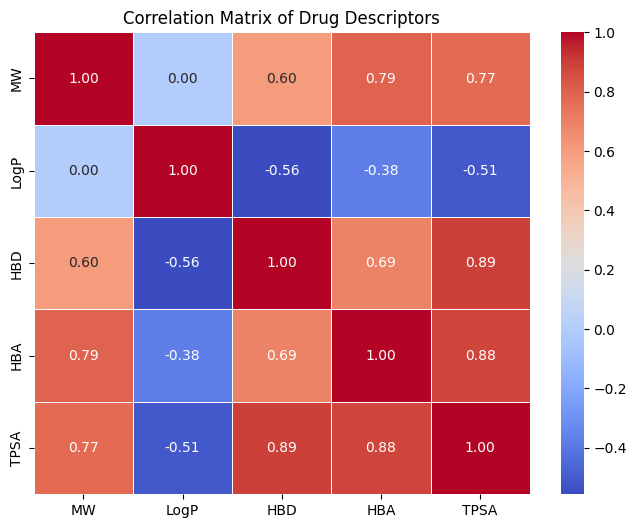

In [54]:
cols = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA']
corr_matrix = df[cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of Drug Descriptors')
plt.savefig('descriptor_correlation.png')

Let's focus on CNS-active drugs and try to filter possible drugs relevant to BBB (Blood-Brain Barrier).
We will use these restrictions:


Potential CNS candidates found: 3608


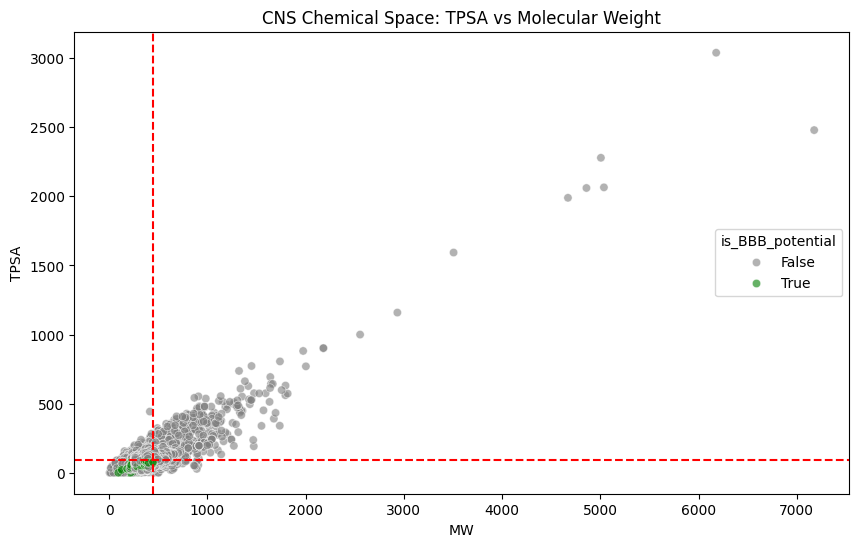

In [55]:
df['is_BBB_potential'] = (
    (df['MW'] < 450) &
    (df['LogP'].between(1, 3)) &
    (df['HBD'] < 3) &
    (df['TPSA'] < 90)
)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='MW', y='TPSA', hue='is_BBB_potential', palette={True: 'green', False: 'grey'}, alpha=0.6)
plt.axhline(90, ls='--', c='red') # TPSA threshold
plt.axvline(450, ls='--', c='red') # MW threshold
plt.title('CNS Chemical Space: TPSA vs Molecular Weight')
plt.savefig('bbb_potential_scatter.png')

print(f"Potential CNS candidates found: {df['is_BBB_potential'].sum()}")

So we see there are some green molecules. Are they drugs?

In [56]:
df_bbb = df[df['is_BBB_potential'] == True]
total_bbb = len(df_bbb)
drugbank_bbb = df_bbb['drugbank_id'].notna().sum()
percentage = (drugbank_bbb / total_bbb) * 100 if total_bbb > 0 else 0

print(f"Total BBB-potential compounds: {total_bbb}")
print(f"In DrugBank: {drugbank_bbb} ({percentage:.2f}%)")

Total BBB-potential compounds: 3608
In DrugBank: 1185 (32.84%)


Some of they seemingly are drugs. Let's have a look on a specific molecule from drugbank from this filtering.

In [57]:
df_bbb.head()

,Canonical_SMILES,drugbank_id,ChEMBL ID,zincid,MW,LogP,HBD,HBA,TPSA,is_BBB_potential
57,O=C(O)CCCCC1CCSS1,58.0,NaN,NaN,206.332,2.7851,1.0,3.0,37.30,True
61,CC1=CC(=O)c2ccccc2C1=O,62.0,NaN,NaN,172.183,2.0119,0.0,2.0,34.14,True
72,NCC(CC(=O)O)c1ccc(Cl)cc1,73.0,NaN,NaN,213.664,1.8570,2.0,2.0,63.32,True
73,CC(N)Cc1ccccc1,74.0,NaN,NaN,135.210,1.5763,1.0,1.0,26.02,True
75,CN1CCC[C@H]1c1cccnc1,76.0,NaN,NaN,162.236,1.8483,0.0,2.0,16.13,True


Now we will take a step back and filter the original df with Lipinski rules.

Lipinski_Pass
True     94.930144
False     5.069856
Name: proportion, dtype: float64


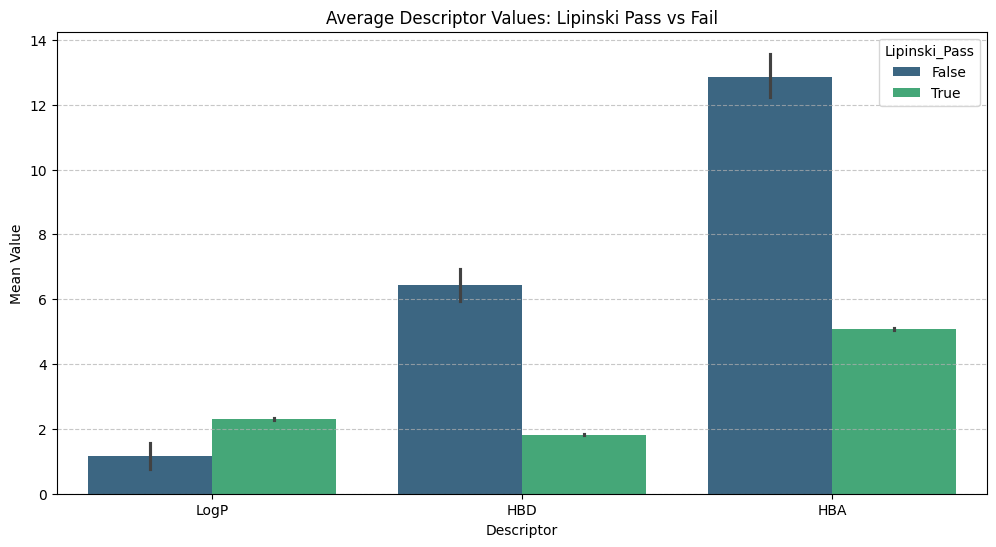

In [58]:
def check_lipinski(row):
    violations = sum([
        row['MW'] > 500,
        row['LogP'] > 5,
        row['HBD'] > 5,
        row['HBA'] > 10
    ])
    return violations <= 1

df['Lipinski_Pass'] = df.apply(check_lipinski, axis=1)

descriptors = ['LogP', 'HBD', 'HBA']
df_melted = df.melt(id_vars=['Lipinski_Pass'], value_vars=descriptors,
                    var_name='Descriptor', value_name='Value')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Descriptor', y='Value', hue='Lipinski_Pass', palette='viridis')

plt.title('Average Descriptor Values: Lipinski Pass vs Fail')
plt.ylabel('Mean Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.savefig('lipinski_barplots.png')

print(df['Lipinski_Pass'].value_counts(normalize=True) * 100)

We should make sure that check_lipinski works ok:

In [59]:
df[df['Lipinski_Pass'] == False][['MW', 'LogP', 'HBD', 'HBA']].head()

,MW,LogP,HBD,HBA
0,2180.317,-8.11643,28.0,29.0
1,1269.433,-3.10570,17.0,16.0
2,1069.238,-4.13203,14.0,15.0
3,1431.064,-0.50613,17.0,16.0
4,1202.635,3.26900,5.0,12.0


So it looks ok.

Now what about the specific databases? Let's compare.

Percentage of molecules passing Lipinski's Rule: 94.93%
DrugBank Lipinski Failure Rate: 10.11%
ChEMBL Lipinski Failure Rate: 5.18%
ZINC Lipinski Failure Rate: 0.00%


C:\Users\souku\AppData\Local\Temp\ipykernel_14780\69348488.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='Reds')


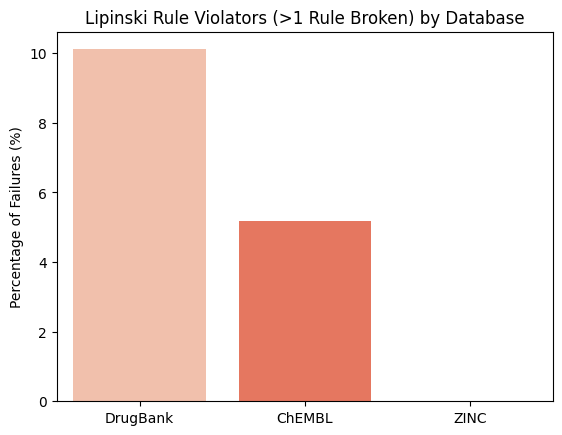

In [60]:
pass_percentage = df['Lipinski_Pass'].mean() * 100
print(f"Percentage of molecules passing Lipinski's Rule: {pass_percentage:.2f}%")

# 1. Define the databases and their respective ID columns
db_cols = {'drugbank_id': 'DrugBank', 'ChEMBL ID': 'ChEMBL', 'zincid': 'ZINC'}

# 2. Calculate percentage of False (violations > 1) per database
results = {}
for col, name in db_cols.items():
    # Filter rows belonging to this database
    db_subset = df[df[col].notna()]

    if len(db_subset) > 0:
        # Percentage where Lipinski_Pass is False
        fail_pct = (db_subset['Lipinski_Pass'] == False).mean() * 100
        results[name] = fail_pct
    else:
        results[name] = 0

# 3. Print and Plot
for db, pct in results.items():
    print(f"{db} Lipinski Failure Rate: {pct:.2f}%")

sns.barplot(x=list(results.keys()), y=list(results.values()), palette='Reds')
plt.ylabel('Percentage of Failures (%)')
plt.title('Lipinski Rule Violators (>1 Rule Broken) by Database')
plt.show()

So interesting that it is mostly DrugBank... Well we see that not all drugs pass the Lipinski rules.

And just because we have some time, we will filter molecules with both aliphatic and aromatic nitrogen:

In [61]:
#SMARTS
aliphatic_n_pattern = Chem.MolFromSmarts("[N;!a]")  # only aromatic
aromatic_n_pattern = Chem.MolFromSmarts("[n;a]")    # only non-aromatic with nitrogen

def has_both_nitrogens(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        has_aliphatic = mol.HasSubstructMatch(aliphatic_n_pattern)
        has_aromatic = mol.HasSubstructMatch(aromatic_n_pattern)
        return has_aliphatic and has_aromatic
    return False

df['both_N_types'] = df['Canonical_SMILES'].apply(has_both_nitrogens)
df_nitrogen_filtered = df[df['both_N_types'] == True]

total_found = len(df_nitrogen_filtered)
print(f"Molecules with both Aliphatic and Aromatic Nitrogen: {total_found}\n")

db_cols = {'drugbank_id': 'DrugBank', 'ChEMBL ID': 'ChEMBL', 'zincid': 'ZINC'}

for col, name in db_cols.items():
    db_subset = df[df[col].notna()]
    if len(db_subset) > 0:
        pct = (db_subset['both_N_types']).mean() * 100
        print(f"{name}: {pct:.2f}% contain both nitrogen types.")

Molecules with both Aliphatic and Aromatic Nitrogen: 10761

DrugBank: 28.37% contain both nitrogen types.
ChEMBL: 95.34% contain both nitrogen types.
ZINC: 60.71% contain both nitrogen types.


More filters:
### Veber
    * Rotatable bonds <= 10
    * Polar surface area TPSA <= 140
* allows higher molecular weight
* 2002

### Ghose
    * Partition Coefficient (log P)     -0.4 - 5.6
    * Molar Refractivity (MR)           40 - 130 cm^3/mol
    * Molecular Weight (MW)             160 - 480 Da
    * Total Number of Atoms             20 - 70
* more flexible about lipophilicity
* more restrictive about size
* 1999